<a href="https://colab.research.google.com/github/Coii1/ph-real-estate-price-prediction/blob/main/Final_Notebook_(used_in_final_paper).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive
from sklearn.cluster import KMeans

In [ ]:
# ------------------------------------------
# 1. Mount Google Drive
# ------------------------------------------
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ------------------------------------------
# 2. Set file path
# Example:
# MyDrive/notebooks/philippines_housing.csv
# ------------------------------------------
file_path = "/content/drive/Shareddrives/shareddrive1/197 final_project/data/Housing_geocoded.csv"

# Read CSV
df = pd.read_csv(file_path)

# ----------------------------------------------------------
# Inspect missing values first
# ----------------------------------------------------------
print("Missing values before imputation:")
print(df.isnull().sum())

Missing values before imputation:
Description     0
Location        4
Price          49
Bedrooms       63
Bathrooms      80
Floor Area     37
Land Area      23
Latitude        1
Longitude       1
dtype: int64


In [ ]:
df.shape

(1500, 9)

In [ ]:
# ==========================================================
# CREATE MISSING FLAG COLUMNS (recommended)
# ==========================================================

#read original file with missing values for lat and long
housing_v2_path = "/content/drive/Shareddrives/shareddrive1/197 final_project/data/Housing_v2.csv"

# Read CSV
housing_v2 = pd.read_csv(housing_v2_path)


cols_track = [
    "Latitude", "Longitude",
    "Land Area", "Floor Area",
    "Bedrooms", "Bathrooms"
]

for col in cols_track:
    if col in df.columns:
        safe_name = col.lower().replace(" ", "_") + "_was_missing"
        df[safe_name] = housing_v2[col].isnull().astype(int)

housing_v2.shape

(1500, 9)

In [ ]:
# ------------------------------------------
# 3. Remove rows with missing Price
# ------------------------------------------
df = df.dropna(subset=["Price"])

# ----------------------------------------------------------
# Inspect missing values first
# ----------------------------------------------------------
print("Missing values before imputation:")
print(df.isnull().sum())

Missing values before imputation:
Description                0
Location                   4
Price                      0
Bedrooms                  62
Bathrooms                 78
Floor Area                35
Land Area                 21
Latitude                   1
Longitude                  1
latitude_was_missing       0
longitude_was_missing      0
land_area_was_missing      0
floor_area_was_missing     0
bedrooms_was_missing       0
bathrooms_was_missing      0
dtype: int64


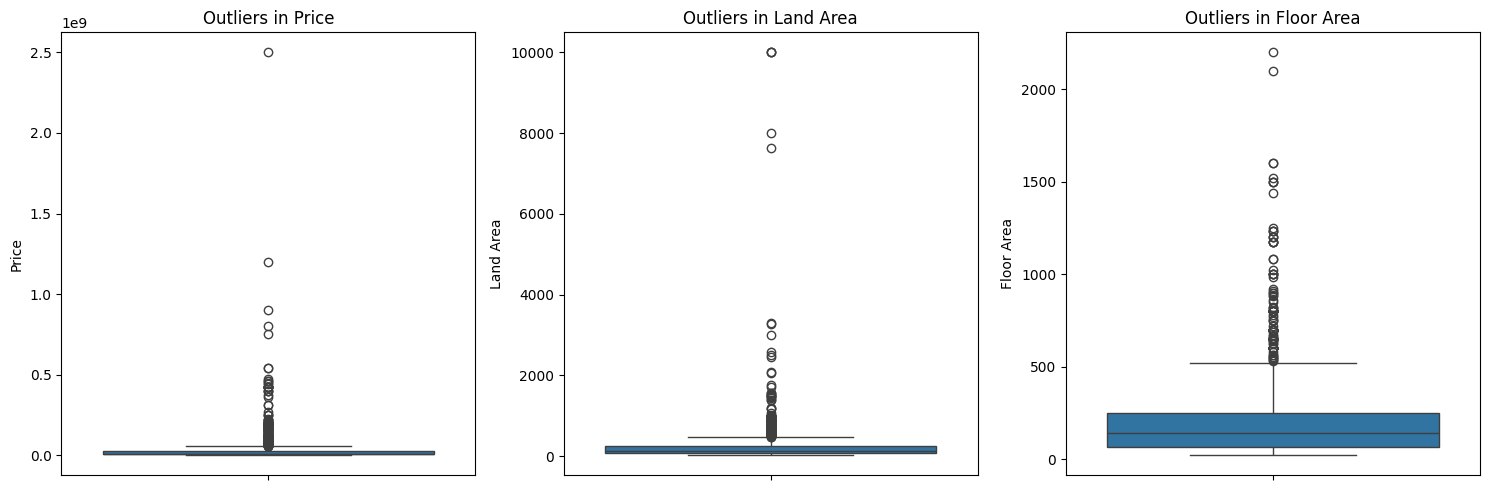

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Columns to investigate
cols = ["Price", "Land Area", "Floor Area"]

plt.figure(figsize=(15, 5))
for i, col in enumerate(cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(f"Outliers in {col}")

plt.tight_layout()
plt.show()

In [ ]:
#may need a lot of tailoring later, after knowing how the code works
# Fill missing Location using Description clues

muntinlupa_string = "Likha Residences, Muntinlupa City, Metro Manila"

df.loc[159, "Location"] = muntinlupa_string
df.loc[296, "Location"] = muntinlupa_string
df.loc[300, "Location"] = muntinlupa_string

df.loc[1389, "Location"] = "Santa Rosa, Laguna"

# Using .at for high-speed scalar assignment
df.at[1389, 'Latitude'] = 14.26823
df.at[1389, 'Longitude'] = 121.07158

# Verify the update
print(df.loc[1389])

# ----------------------------------------------------------
# Inspect missing values first
# ----------------------------------------------------------
print("Missing values before imputation:")
print(df.isnull().sum())

Description               [04783-C-251] House & Lot for sale in Laguna B...
Location                                                 Santa Rosa, Laguna
Price                                                             6800000.0
Bedrooms                                                                4.0
Bathrooms                                                               3.0
Floor Area                                                           187.17
Land Area                                                             137.0
Latitude                                                           14.26823
Longitude                                                         121.07158
latitude_was_missing                                                      1
longitude_was_missing                                                     1
land_area_was_missing                                                     0
floor_area_was_missing                                                    0
bedrooms_was

In [ ]:
# ==========================================================
# STEP 3: CREATE LOCATION CLUSTERS USING KMEANS
# Recommended: start with 15 clusters, tune later
# ==========================================================
from sklearn.cluster import KMeans

coords = df[["Latitude", "Longitude"]]

kmeans = KMeans(
    n_clusters=28,
    random_state=42,
    n_init=10
)

df["geo_cluster"] = kmeans.fit_predict(coords)

df['geo_cluster'].value_counts()

,count
geo_cluster,
1,295
11,287
24,116
22,95
8,89
3,79
14,74
7,70
16,61


In [ ]:
# ==========================================================
# STEP 4: IMPUTE LAND AREA
# Group = geo_cluster, location
# Fallback = global median
# ==========================================================
df["Land Area"] = df["Land Area"].fillna(
    df.groupby("Location")["Land Area"].transform("median")
)

df["Land Area"] = df["Land Area"].fillna(
    df.groupby("geo_cluster")["Land Area"].transform("median")
)

# ----------------------------------------------------------
# Inspect missing values first
# ----------------------------------------------------------
print("Missing values before imputation:")
print(df.isnull().sum())

Missing values before imputation:
Description                0
Location                   0
Price                      0
Bedrooms                  62
Bathrooms                 78
Floor Area                35
Land Area                  0
Latitude                   0
Longitude                  0
latitude_was_missing       0
longitude_was_missing      0
land_area_was_missing      0
floor_area_was_missing     0
bedrooms_was_missing       0
bathrooms_was_missing      0
geo_cluster                0
dtype: int64


In [ ]:
# ==========================================================
# STEP 5: BIN LAND AREA
# Used for Floor Area imputation
# ==========================================================
df["land_bin"] = pd.qcut(
    df["Land Area"],
    q=5,
    duplicates="drop"
)

In [ ]:
# ==========================================================
# STEP 6: IMPUTE FLOOR AREA
# Group = geo_cluster, land_bin, location, combinations
# Fallbacks:
#   geo_cluster only
#   global median
# ==========================================================
df["Floor Area"] = df["Floor Area"].fillna(
    df.groupby(["Location", "land_bin"])["Floor Area"].transform("median")
)

df["Floor Area"] = df["Floor Area"].fillna(
    df.groupby(["geo_cluster", "land_bin"])["Floor Area"].transform("median")
)

df["Floor Area"] = df["Floor Area"].fillna(
    df.groupby("Location")["Floor Area"].transform("median")
)

df["Floor Area"] = df["Floor Area"].fillna(
    df.groupby("geo_cluster")["Floor Area"].transform("median")
)

# ----------------------------------------------------------
# Inspect missing values first
# ----------------------------------------------------------
print("Missing values before imputation:")
print(df.isnull().sum())# ----------------------------------------------------------

Missing values before imputation:
Description                0
Location                   0
Price                      0
Bedrooms                  62
Bathrooms                 78
Floor Area                 0
Land Area                  0
Latitude                   0
Longitude                  0
latitude_was_missing       0
longitude_was_missing      0
land_area_was_missing      0
floor_area_was_missing     0
bedrooms_was_missing       0
bathrooms_was_missing      0
geo_cluster                0
land_bin                   0
dtype: int64


/tmp/ipykernel_568/3463554118.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["Location", "land_bin"])["Floor Area"].transform("median")
/tmp/ipykernel_568/3463554118.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["geo_cluster", "land_bin"])["Floor Area"].transform("median")


In [ ]:
# ==========================================================
# STEP 7: BIN FLOOR AREA
# Used for Bedrooms / Bathrooms
# ==========================================================
df["floor_bin"] = pd.qcut(
    df["Floor Area"],
    q=5,
    duplicates="drop"
)


# ==========================================================
# HELPER FUNCTION: MODE IMPUTATION
# ==========================================================
def grouped_mode_fill(dataframe, target_col, group_cols):
    """
    Fill missing values using mode within groups.
    """
    mode_map = dataframe.groupby(group_cols)[target_col].agg(
        lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
    )

    def fill_row(row):
        if pd.isnull(row[target_col]):
            key = tuple(row[g] for g in group_cols)
            if len(group_cols) == 1:
                key = key[0]
            return mode_map.get(key, np.nan)
        return row[target_col]

    dataframe[target_col] = dataframe.apply(fill_row, axis=1)
    return dataframe

In [ ]:
# ==========================================================
# STEP 8: IMPUTE BEDROOMS (MODE)
# Group = geo_cluster,floor_bin, location etc.
# Fallbacks:
#   geo_cluster
#   global mode
# ==========================================================
df = grouped_mode_fill(df, "Bedrooms", ["Location", "floor_bin"])
df = grouped_mode_fill(df, "Bedrooms", ["geo_cluster", "floor_bin"])
df = grouped_mode_fill(df, "Bedrooms", ["Location", "land_bin"])
df = grouped_mode_fill(df, "Bedrooms", ["geo_cluster", "land_bin"])
df = grouped_mode_fill(df, "Bedrooms", ["Location"])
df = grouped_mode_fill(df, "Bedrooms", ["geo_cluster"])

# ----------------------------------------------------------
# Inspect missing values first
# ----------------------------------------------------------
print("Missing values before imputation:")
print(df.isnull().sum())

/tmp/ipykernel_568/2532603493.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mode_map = dataframe.groupby(group_cols)[target_col].agg(
/tmp/ipykernel_568/2532603493.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mode_map = dataframe.groupby(group_cols)[target_col].agg(
/tmp/ipykernel_568/2532603493.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mode_map = dataframe.groupby(group_cols)[target_col].agg(
/

Missing values before imputation:
Description                0
Location                   0
Price                      0
Bedrooms                   0
Bathrooms                 78
Floor Area                 0
Land Area                  0
Latitude                   0
Longitude                  0
latitude_was_missing       0
longitude_was_missing      0
land_area_was_missing      0
floor_area_was_missing     0
bedrooms_was_missing       0
bathrooms_was_missing      0
geo_cluster                0
land_bin                   0
floor_bin                  0
dtype: int64


In [ ]:
# ==========================================================
# STEP 9: IMPUTE BATHROOMS (MODE)
# Group = geo_cluster, floor_bin etc.
# Fallbacks:
#   geo_cluster
#   global mode
# ==========================================================
df = grouped_mode_fill(df, "Bathrooms", ["Location", "floor_bin"])
df = grouped_mode_fill(df, "Bathrooms", ["geo_cluster", "floor_bin"])
df = grouped_mode_fill(df, "Bathrooms", ["Location", "land_bin"])
df = grouped_mode_fill(df, "Bathrooms", ["geo_cluster", "land_bin"])
df = grouped_mode_fill(df, "Bathrooms", ["Location"])
df = grouped_mode_fill(df, "Bathrooms", ["geo_cluster"])


# ==========================================================
# STEP 10: CLEAN TYPES
# Bedrooms/Bathrooms should be integers
# ==========================================================
df["Bedrooms"] = df["Bedrooms"].round().astype(int)
df["Bathrooms"] = df["Bathrooms"].round().astype(int)

# ----------------------------------------------------------
# Inspect missing values first
# ----------------------------------------------------------
print("Missing values before imputation:")
print(df.isnull().sum())

/tmp/ipykernel_568/2532603493.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mode_map = dataframe.groupby(group_cols)[target_col].agg(
/tmp/ipykernel_568/2532603493.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mode_map = dataframe.groupby(group_cols)[target_col].agg(
/tmp/ipykernel_568/2532603493.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mode_map = dataframe.groupby(group_cols)[target_col].agg(


Missing values before imputation:
Description               0
Location                  0
Price                     0
Bedrooms                  0
Bathrooms                 0
Floor Area                0
Land Area                 0
Latitude                  0
Longitude                 0
latitude_was_missing      0
longitude_was_missing     0
land_area_was_missing     0
floor_area_was_missing    0
bedrooms_was_missing      0
bathrooms_was_missing     0
geo_cluster               0
land_bin                  0
floor_bin                 0
dtype: int64


/tmp/ipykernel_568/2532603493.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mode_map = dataframe.groupby(group_cols)[target_col].agg(


In [ ]:
# ==========================================================
# STEP 11: OPTIONAL REMOVE TEMP BIN COLUMNS
# Keep geo_cluster (useful feature)
# ==========================================================
df.drop(columns=["land_bin", "floor_bin"], inplace=True)

In [ ]:
# ==========================================================
# STEP 12: IMPROVED OUTLIER HANDLING
# Strategy:
# 1. Statistical Clipping (IQR) for univariate outliers
# 2. Logical Consistency Check (Price vs Area) for multivariate outliers
# ==========================================================

# --- (a) Statistical Clipping (IQR) ---
outlier_cols = ["Price", "Land Area", "Floor Area"]

for col in outlier_cols:
    Q1 = df[col].quantile(0.10)
    Q3 = df[col].quantile(0.90)
    IQR = Q3 - Q1

    # 1.5 * IQR is the standard rule for "outliers"
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Clip to these bounds
    df[col] = df[col].clip(lower=max(0, lower_bound), upper=upper_bound)

# --- (b) Logical Consistency Check (THE RMSE FIX) ---
# This removes rows where the relationship between Price and Area makes no sense
initial_count = len(df)

# Calculate temporary Price per SQM to find "hallucination" points
df['temp_price_per_sqm'] = df['Price'] / (df['Floor Area'] + 1)

# Remove the top 0.5% and bottom 0.5% of "Price per SQM"
# These are usually data entry errors (e.g., missing a zero in area)
sqm_upper = df['temp_price_per_sqm'].quantile(0.995)
sqm_lower = df['temp_price_per_sqm'].quantile(0.005)

df = df[(df['temp_price_per_sqm'] < sqm_upper) & (df['temp_price_per_sqm'] > sqm_lower)]

# Cleanup
df.drop(columns=['temp_price_per_sqm'], inplace=True)

print(f"IQR Clipping complete.")
print(f"Logical consistency check removed {initial_count - len(df)} suspicious rows.")
print(df[["Price", "Land Area", "Floor Area"]].describe())

IQR Clipping complete.
Logical consistency check removed 16 suspicious rows.
              Price    Land Area   Floor Area
count  1.435000e+03  1435.000000  1435.000000
mean   2.354604e+07   206.982056   208.618990
std    3.627938e+07   220.800779   207.516638
min    8.690000e+05    27.000000    22.000000
25%    4.944000e+06    80.000000    67.500000
50%    9.200000e+06   121.000000   142.000000
75%    2.500000e+07   239.500000   250.000000
max    1.546912e+08  1100.000000  1056.000000


In [ ]:
# ==========================================================
# FINAL CHECK
# ==========================================================
print("\nMissing values after imputation:")
print(df.isnull().sum())


Missing values after imputation:
Description               0
Location                  0
Price                     0
Bedrooms                  0
Bathrooms                 0
Floor Area                0
Land Area                 0
Latitude                  0
Longitude                 0
latitude_was_missing      0
longitude_was_missing     0
land_area_was_missing     0
floor_area_was_missing    0
bedrooms_was_missing      0
bathrooms_was_missing     0
geo_cluster               0
dtype: int64


In [ ]:
#uncomment this code once dataframe is fully cleaned



output_path = "/content/drive/Shareddrives/shareddrive1/197 final_project/data/cleaned_data.csv"
# output_path = "/content/cleaned_data.csv"

df.to_csv(output_path, index=False)

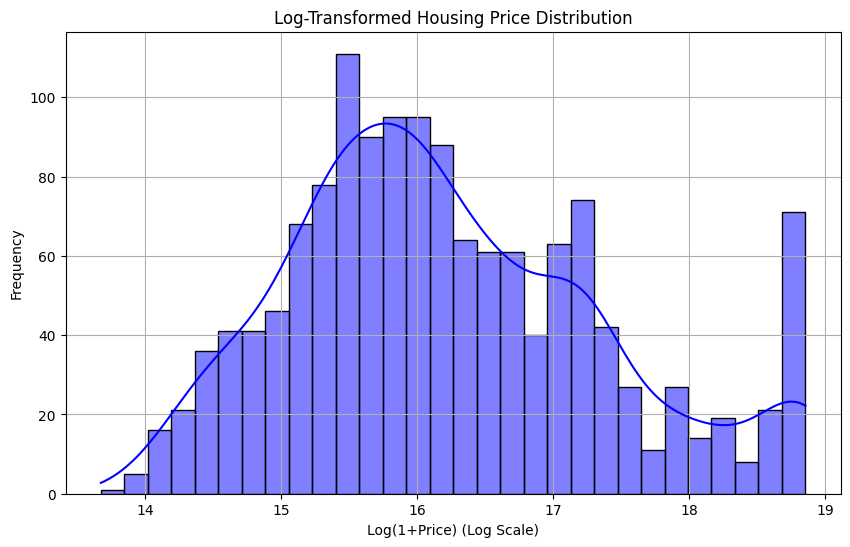

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


# Create the plot
plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(df['Price']), kde=True, bins=30, color='blue')

plt.title("Log-Transformed Housing Price Distribution")
plt.xlabel("Log(1+Price) (Log Scale)")
plt.ylabel("Frequency")
plt.grid(True)
plt.savefig('/content/drive/Shareddrives/shareddrive1/197 final_project/plots/price_distribution.png', dpi=300)
plt.show()

Transform raw data into specialized signals (helps with Gradient Boosting and Neural Nets)

Step 1: Calculate Spatial Distance (Major Hubs to Property) with Haversine Formula
- define Hubs in dictionary of coordinates
- use Haversine formula to calculate the distance between property's coordinates and the hubs
- should output a new col "distance_to_nearest_hub"

In [ ]:
import pandas as pd
import numpy as np

# Load cleaned data
df = pd.read_csv('/content/drive/Shareddrives/shareddrive1/197 final_project/data/cleaned_data.csv')
# Identify and drop all columns ending with '_was_missing'
cols_to_drop = [c for c in df.columns if c.endswith('_was_missing')]
df = df.drop(columns=cols_to_drop)

print(f"Dropped {len(cols_to_drop)} indicator columns.")
# Calculate the distance between property's coordinates and the major hubs bc coordinates are difficult for ML to understand
def haversine(lat1, long1, lat2, long2):
    # Convert degrees to radians
    lat1, long1, lat2, long2 = map(np.radians, [lat1, long1, lat2, long2])

    # Differences in coordinates
    dlat = lat2 - lat1
    dlong = long2 - long1

    # Haversine formula
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlong/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))

    # Radius of Earth in kilometers
    km = 6371
    return c * km

# Hashmap of major hubs referenced from https://pdp.depdev.gov.ph/wp-content/uploads/2023/01/PDP-2023-2028.pdf
hubs = {
    'Makati_CBD': (14.5547, 121.0244),
    'BGC': (14.5409, 121.0503),
    'Cebu_IT_Park': (10.3288, 123.9061),
    'Davao_City_Center': (7.0707, 125.6087),
    'Iloilo_Business_Park': (10.7202, 122.5447)
}

# Find the distance to the closest hub
def get_min_distance(prop_lat, prop_long, hub_dict):
    distances = []
    for hub_name, hub_coords in hub_dict.items():
        d = haversine(prop_lat, prop_long, hub_coords[0], hub_coords[1])
        distances.append(d)
    return min(distances)

# Apply to dataframe to create the new feature
df['dist_to_nearest_hub'] = df.apply(
    lambda row: get_min_distance(row['Latitude'], row['Longitude'], hubs),
    axis=1
)

print(df[['Location', 'dist_to_nearest_hub']].head())

Dropped 6 indicator columns.
                                         Location  dist_to_nearest_hub
0                           Santo Domingo, Cainta             8.624932
1                        San Vicente, Santa Maria            28.233361
2      Camella Tarlac Access Rd. Maliwalo, Tarlac           112.731082
3                 Zambowood Rd. Boalan, Zamboanga           385.829215
4  Remulla Drive Tanza-Naic Rd. Sahud Ulan, Tanza            27.008638


Step 2: Text Analysis (Extract Categories) - turn description col into categorical data
- use Python to look for specific terms in description (e.g. townhouse, subdivision, 5 story)
- create new col for these (e.g. is_townhouse col gets a 1, else 0)
- refine: raw text -> structured features that the model can read

In [ ]:
# 1. CLEANING
df['Description'] = df['Description'].fillna('').astype(str).str.lower()

# 2. PROPERTY TYPES
df['is_house_and_lot'] = df['Description'].apply(lambda x: 1 if 'house and lot' in x or 'house & lot' in x else 0)
df['is_townhouse'] = df['Description'].apply(lambda x: 1 if 'townhouse' in x else 0)
df['is_subdivision'] = df['Description'].apply(lambda x: 1 if 'subdivision' in x or 'village' in x else 0)

# 3. BUILDING TYPE
df['is_single_attached'] = df['Description'].apply(lambda x: 1 if 'single attached' in x else 0)
df['is_single_detached'] = df['Description'].apply(lambda x: 1 if 'single detached' in x else 0)

# 4. STRUCTURE & VERTICALITY
df['is_multi_story'] = df['Description'].apply(
    lambda x: 1 if any(word in x for word in ['story', 'storey', 'floor', 'level']) else 0
)

# 5. MARKET STATUS (crucial for price differences)
df['is_rfo'] = df['Description'].apply(lambda x: 1 if 'rfo' in x or 'ready for occupancy' in x else 0)
df['is_preselling'] = df['Description'].apply(lambda x: 1 if 'preselling' in x or 'pre-selling' in x else 0)

# 6. LUXURY & AMENITIES
df['has_pool'] = df['Description'].apply(lambda x: 1 if 'pool' in x or 'swimming' in x else 0)
df['is_corner_lot'] = df['Description'].apply(lambda x: 1 if 'corner lot' in x else 0)
df['is_modern'] = df['Description'].apply(lambda x: 1 if 'modern' in x or 'brand new' in x else 0)
# Added back 'has_garage' so your print statement works!
df['has_garage'] = df['Description'].apply(lambda x: 1 if any(word in x for word in ['garage', 'parking', 'carport']) else 0)

# 7. BRANDING
df['is_camella'] = df['Description'].apply(lambda x: 1 if 'camella' in x else 0)

# CHECK THE RESULTS
print("Keyword Counts Found in your CSV:")
cols = ['is_house_and_lot', 'is_townhouse', 'is_rfo', 'is_preselling', 'is_multi_story', 'is_camella', 'has_garage']
print(df[cols].sum())

# Preview the final engineered features
cols_to_show = ['Location', 'dist_to_nearest_hub', 'is_townhouse', 'is_multi_story', 'has_garage', 'is_camella']
print(df[cols_to_show].head())

Keyword Counts Found in your CSV:
is_house_and_lot    706
is_townhouse        304
is_rfo              105
is_preselling        35
is_multi_story      429
is_camella          255
has_garage           42
dtype: int64
                                         Location  dist_to_nearest_hub  \
0                           Santo Domingo, Cainta             8.624932   
1                        San Vicente, Santa Maria            28.233361   
2      Camella Tarlac Access Rd. Maliwalo, Tarlac           112.731082   
3                 Zambowood Rd. Boalan, Zamboanga           385.829215   
4  Remulla Drive Tanza-Naic Rd. Sahud Ulan, Tanza            27.008638   

   is_townhouse  is_multi_story  has_garage  is_camella  
0             1               1           0           0  
1             0               0           0           0  
2             0               1           0           1  
3             1               0           0           0  
4             0               0           0       

Step 3: Area to Room Ratio
- calculate: divide Floor Area by number of Bedrooms
- insight: high ratio -> luxury property with large rooms; low ratio -> high-density

In [ ]:
# Calculate the Ratio

# Use .replace(0, 1) so that studio units (0 BR) are treated as 1-room units
# to avoid division by zero errors
df['area_to_room_ratio'] = df['Floor Area'] / df['Bedrooms'].replace(0, 1)

# Verify if the ratio is working correctly.
def get_density_label(ratio):
    if ratio > 50: return 'Luxury/Spacious'
    elif ratio > 25: return 'Standard'
    else: return 'High-Density'

# Check results
print("Area to Room Ratio Insights:")
print(df[['Location', 'Floor Area', 'Bedrooms', 'area_to_room_ratio']].head())

# See how many 'Spacious' vs 'High-Density' homes
temp_labels = df['area_to_room_ratio'].apply(get_density_label)
print("\nProperty Density Distribution:")
print(temp_labels.value_counts())

Area to Room Ratio Insights:
                                         Location  Floor Area  Bedrooms  \
0                           Santo Domingo, Cainta      144.00         4   
1                        San Vicente, Santa Maria       63.20         3   
2      Camella Tarlac Access Rd. Maliwalo, Tarlac      100.00         5   
3                 Zambowood Rd. Boalan, Zamboanga       40.32         2   
4  Remulla Drive Tanza-Naic Rd. Sahud Ulan, Tanza       39.64         3   

   area_to_room_ratio  
0           36.000000  
1           21.066667  
2           20.000000  
3           20.160000  
4           13.213333  

Property Density Distribution:
area_to_room_ratio
Luxury/Spacious    563
Standard           451
High-Density       421
Name: count, dtype: int64


In [ ]:
# Right after loading
df = pd.read_csv(file_path)
print(f"Initial: {len(df)} rows")

# After dropping missing Price
df = df.dropna(subset=["Price"])
print(f"After removing missing Price: {len(df)} rows")

# After imputation (should be same as above)
print(f"After imputation: {len(df)} rows")

# After outlier filtering
print(f"Final clean dataset: {len(df)} rows")
print(f"Data retention: {len(df)/1500*100:.1f}%")

# Final verification
print(f"Shape with all features: {df.shape}")  # Should be (1435, 28)
print(f"Missing values: {df.isnull().sum().sum()}")  # Should be 0

Initial: 1500 rows
After removing missing Price: 1451 rows
After imputation: 1451 rows
Final clean dataset: 1451 rows
Data retention: 96.7%
Shape with all features: (1451, 9)
Missing values: 202


Step 4: Target Encoding for Location since there are too many cities and barangays for simple numbers
- replace name of location (e.g. Makati) with the avg. price of all properties in that location (this means Makati would have higher prices if avg is high without needing multiple columns)

In [ ]:
# # Calculate the mean price for each unique Location

# # This creates a "Price Map" of the Philippines based on the data
# location_target_mean = df.groupby('Location')['Price'].mean()

# # Map the averages back to the dataframe to create the 'location_price_index'
# df['location_price_index'] = df['Location'].map(location_target_mean)

# # Handle "Outliers" or Unique Locations (Smoothing)

# # If a location only appears once, or is missing, fill it with the
# # global average price so the model doesn't crash
# global_mean_price = df['Price'].mean()
# df['location_price_index'] = df['location_price_index'].fillna(global_mean_price)

# # Check
# print("Target Encoding (Location Price Index):")
# print(df[['Location', 'Price', 'location_price_index']].head())

# Save here to compare PHP peso
df.to_csv('/content/drive/Shareddrives/shareddrive1/197 final_project/data/engineered_data.csv', index=False)

Step 5: Feature Scaling (Standardization)
- transform all numerical cols (e.g. if price is in millions and bedrooms is 1-5, scale to have a mean of 0 and sd = 1)

Price = 0 means it was exactly the average price

Price = 1.5 means it is 1.5 standard deviations higher than average

Price of -0.8 means it is cheaper than average

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# 1. CREATE THE MISSING FEATURES FIRST
# This fixes the KeyError by adding the columns to the dataframe
df['land_per_bed'] = df['Land Area'] / (df['Bedrooms'] + 1)
df['floor_to_land_ratio'] = df['Floor Area'] / (df['Land Area'] + 1)

# 2. SELECT NUMERICAL COLUMNS
numerical_cols = [
    'Bedrooms', 'Bathrooms', 'Floor Area', 'Land Area',
    'dist_to_nearest_hub', 'area_to_room_ratio',
    'land_per_bed', 'floor_to_land_ratio'
]

# 3. INITIALIZE SCALER AND COPY DF
scaler = StandardScaler()
df_scaled = df.copy()

# 4. SCALE THE FEATURES
# Now that the columns exist, this will no longer throw a KeyError
df_scaled[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# 5. LOG-TRANSFORM THE TARGET
# This normalizes the price distribution to improve MAE/RMSE
df_scaled['Price_log'] = np.log1p(df['Price'])

# 6. SAVE RESULTS
output_path = '/content/drive/Shareddrives/shareddrive1/197 final_project/data/final_scaled_data.csv'
df_scaled.to_csv(output_path, index=False)

# 7. VERIFY
print("Columns in df_scaled:", df_scaled.columns.tolist())
print("\nFirst 5 rows of scaled numerical data:")
print(df_scaled[numerical_cols].head())

Columns in df_scaled: ['Description', 'Location', 'Price', 'Bedrooms', 'Bathrooms', 'Floor Area', 'Land Area', 'Latitude', 'Longitude', 'geo_cluster', 'dist_to_nearest_hub', 'is_house_and_lot', 'is_townhouse', 'is_subdivision', 'is_single_attached', 'is_single_detached', 'is_multi_story', 'is_rfo', 'is_preselling', 'has_pool', 'is_corner_lot', 'is_modern', 'has_garage', 'is_camella', 'area_to_room_ratio', 'land_per_bed', 'floor_to_land_ratio', 'Price_log']

First 5 rows of scaled numerical data:
   Bedrooms  Bathrooms  Floor Area  Land Area  dist_to_nearest_hub  \
0  0.315448   0.025593   -0.311500  -0.321588            -0.757240   
1 -0.438998  -0.522557   -0.701003  -0.575298            -0.398906   
2  1.069894   0.025593   -0.523606  -0.439382             1.145245   
3 -1.193445  -1.070707   -0.811297  -0.582547             6.135969   
4 -0.438998  -1.070707   -0.814575  -0.484687            -0.421288   

   area_to_room_ratio  land_per_bed  floor_to_land_ratio  
0           -0.4293

Initial: 1500 rows
After removing missing Price: 1451 rows
After imputation: 1451 rows
Final clean dataset: 1451 rows
Data retention: 96.7%
Shape with all features: (1451, 9)
Missing values: 202


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# 1. LOAD DATA
df_scaled = pd.read_csv('/content/drive/Shareddrives/shareddrive1/197 final_project/data/final_scaled_data.csv')

# 2. PREPARE X & Y
X = df_scaled.drop(columns=['Price', 'Price_log', 'Description', 'Location'], errors='ignore')
y = df_scaled['Price_log']

# 80/20 SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5-FOLD CROSS VALIDATION SETUP
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 3. MODELS
models = {
    "Linear Regression": LinearRegression(),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "Random Forest": RandomForestRegressor(n_estimators=150, max_depth=12, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=150, learning_rate=0.05, max_depth=5, random_state=42),
    "SVM": SVR(kernel='rbf', C=1.0, epsilon=0.1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=150, learning_rate=0.05, max_depth=4, random_state=42),
    "Neural Network (MLP)": MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
}

# 4. EVALUATION LOOP
results_list = []

for name, model in models.items():
    # CV on log scale
    cv_scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='r2')

    model.fit(X_train, y_train)
    y_pred_log = model.predict(X_test)

    # 5. REVERSE LOG TRANSFORM (Back to raw PHP)
    y_test_real = np.expm1(y_test)
    y_pred_real = np.expm1(y_pred_log)

    # 6. METRIC CALCULATION
    r2 = r2_score(y_test, y_pred_log)
    mae = mean_absolute_error(y_test_real, y_pred_real)
    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
    mse = mean_squared_error(y_test_real, y_pred_real)  # Added MSE back
    mape = mean_absolute_percentage_error(y_test_real, y_pred_real)

    results_list.append({
        "Model": name,
        "CV R2 (Log)": round(cv_scores.mean(), 4),
        "Test R2": round(r2, 4),
        "MAE (PHP)": round(mae, 2),
        "RMSE (PHP)": round(rmse, 2),
        "MSE": round(mse, 2),  # Added MSE to results
        "MAPE (%)": round(mape * 100, 2)
    })

# FINAL COMPARISON TABLE
comparison_df = pd.DataFrame(results_list).sort_values(by="Test R2", ascending=False)
print("--- MODEL EVALUATION RESULTS (Log-Transformed Target) ---")
print(comparison_df.to_string(index=False))

--- MODEL EVALUATION RESULTS (Log-Transformed Target) ---
               Model  CV R2 (Log)  Test R2   MAE (PHP)  RMSE (PHP)          MSE  MAPE (%)
             XGBoost       0.8899   0.9272  5729694.96 13181467.68 1.737511e+14     23.39
       Random Forest       0.8856   0.9217  5821175.56 13503306.61 1.823393e+14     24.62
   Gradient Boosting       0.8902   0.9180  6245170.33 14373461.09 2.065964e+14     25.96
                 KNN       0.8334   0.8761  6888771.73 15620766.72 2.440084e+14     32.41
                 SVM       0.8391   0.8732  7632961.07 17148425.23 2.940685e+14     34.86
Neural Network (MLP)       0.2244   0.8647  9806426.54 25687990.46 6.598729e+14     34.51
   Linear Regression       0.7371   0.8181 11456577.20 28651230.44 8.208930e+14     43.25


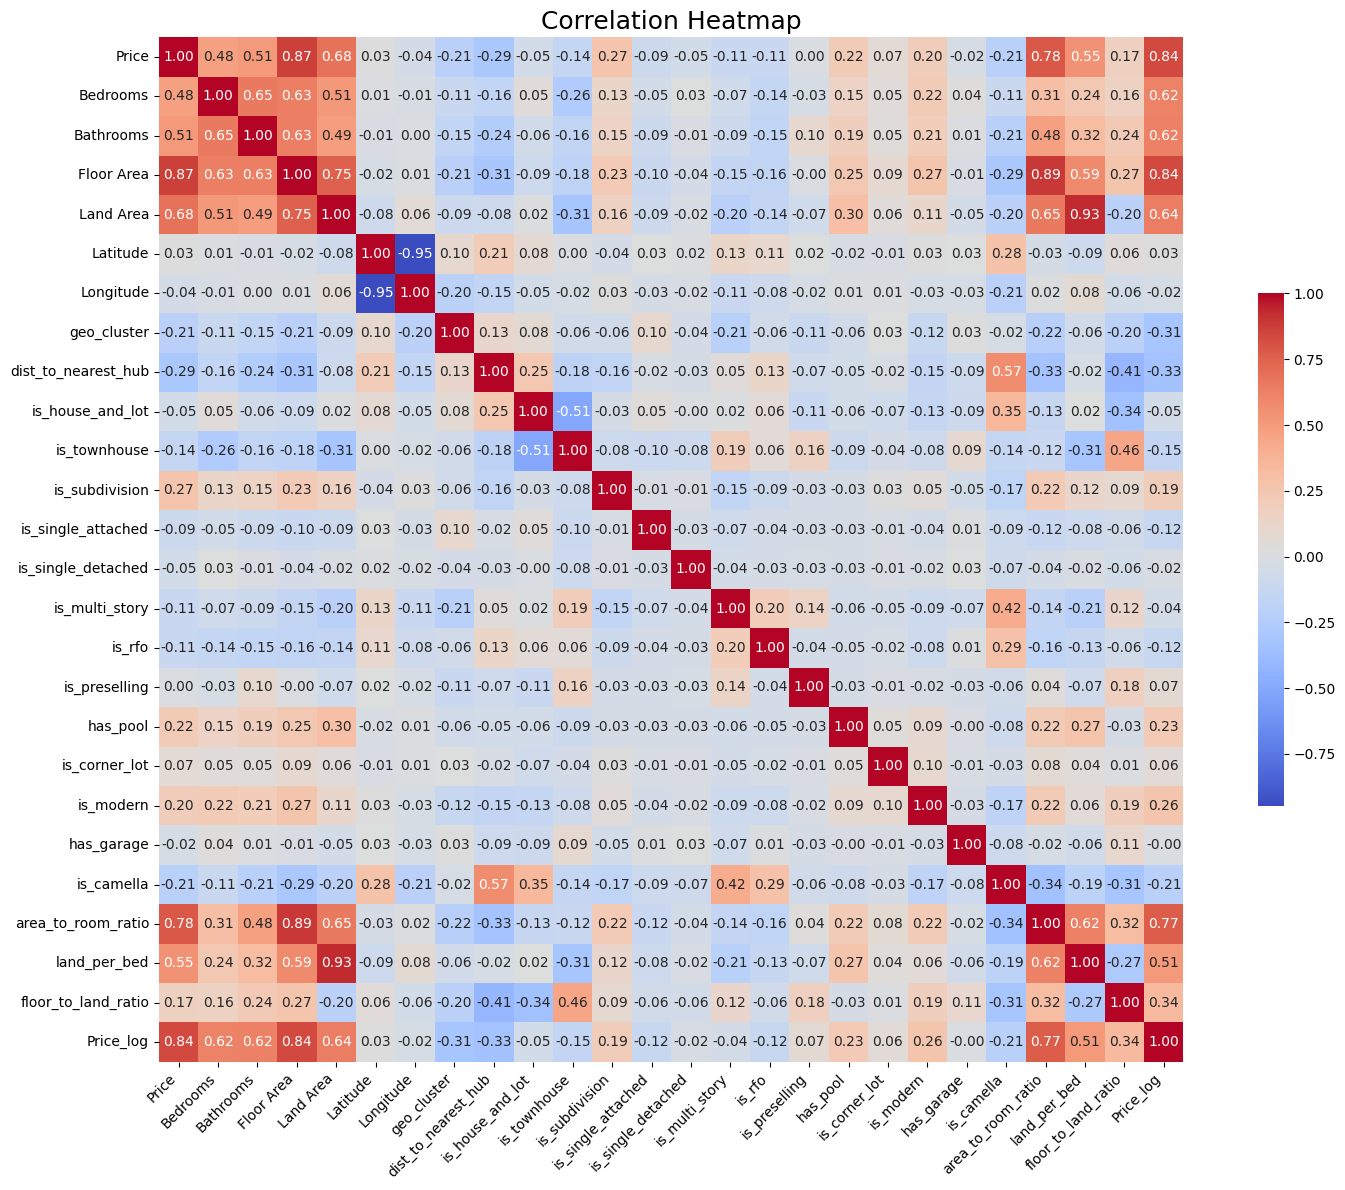

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Heatmap Plot
plt.figure(figsize=(16, 12))

# Select only numerical columns for correlation
numerical_cols = df_scaled.select_dtypes(include=['number']).columns
corr_matrix = df_scaled[numerical_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={'shrink': 0.5})
plt.title("Correlation Heatmap", fontsize=18)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()  # Adjust layout to prevent label cropping
plt.savefig('/content/drive/Shareddrives/shareddrive1/197 final_project/plots/correlation_heatmap.png', dpi=300)
plt.show()

/tmp/ipykernel_568/3824233580.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparison_df["Model"], y=comparison_df["MAPE (%)"], palette="viridis")


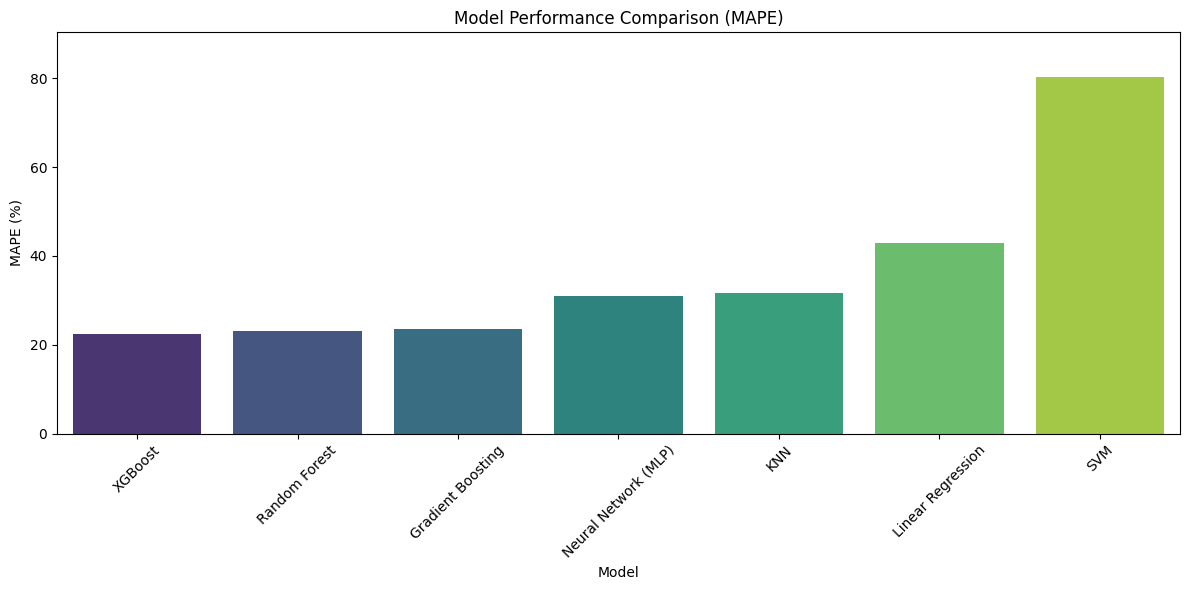

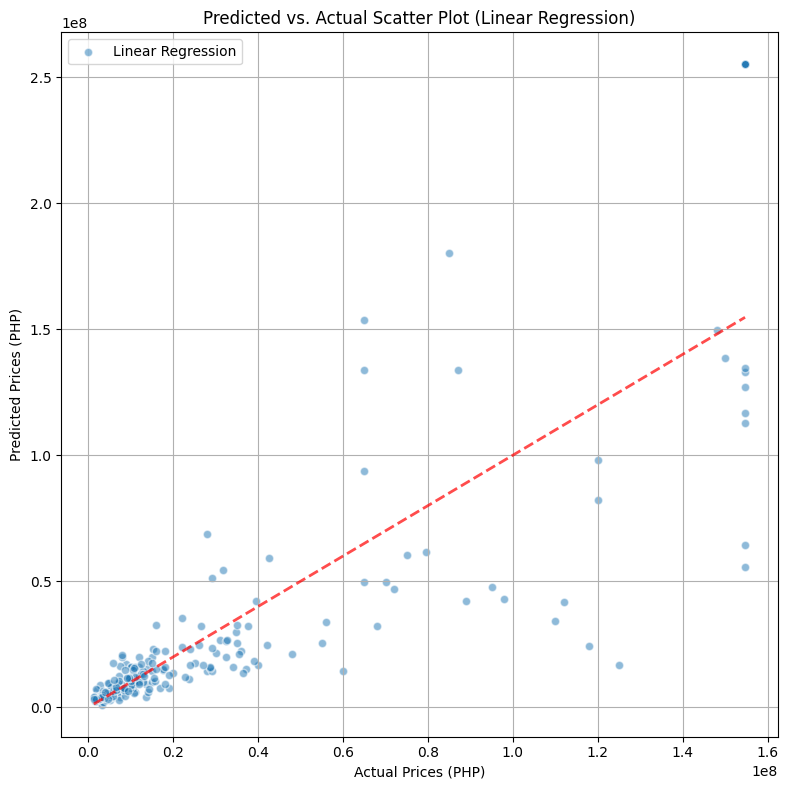

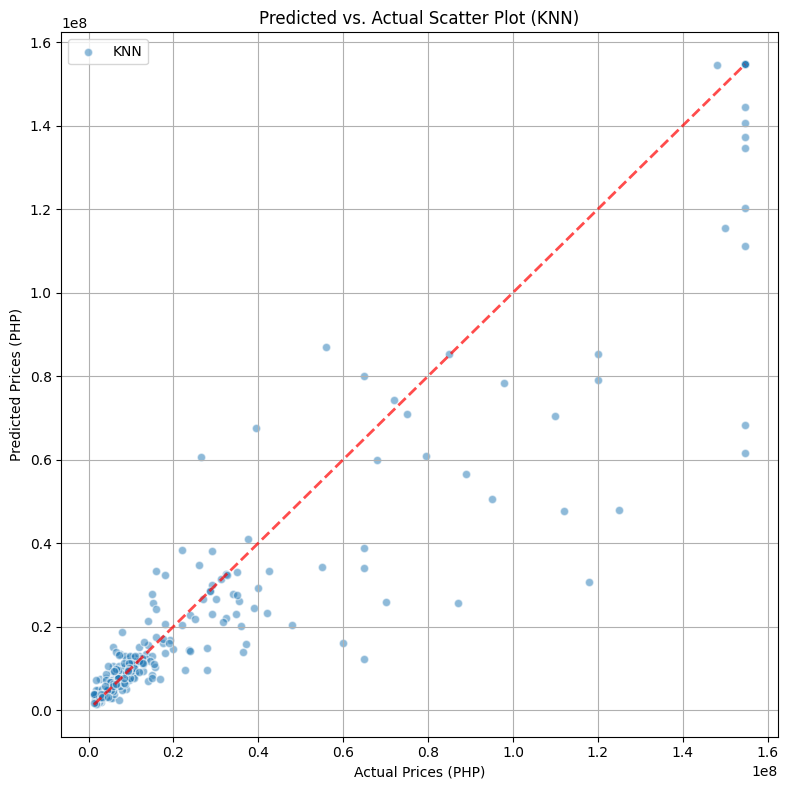

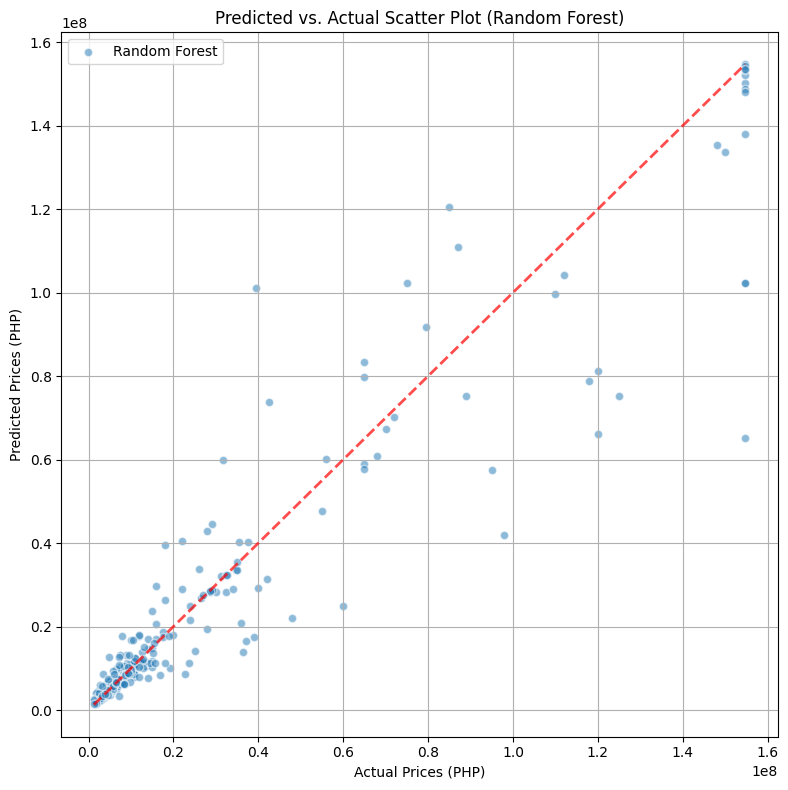

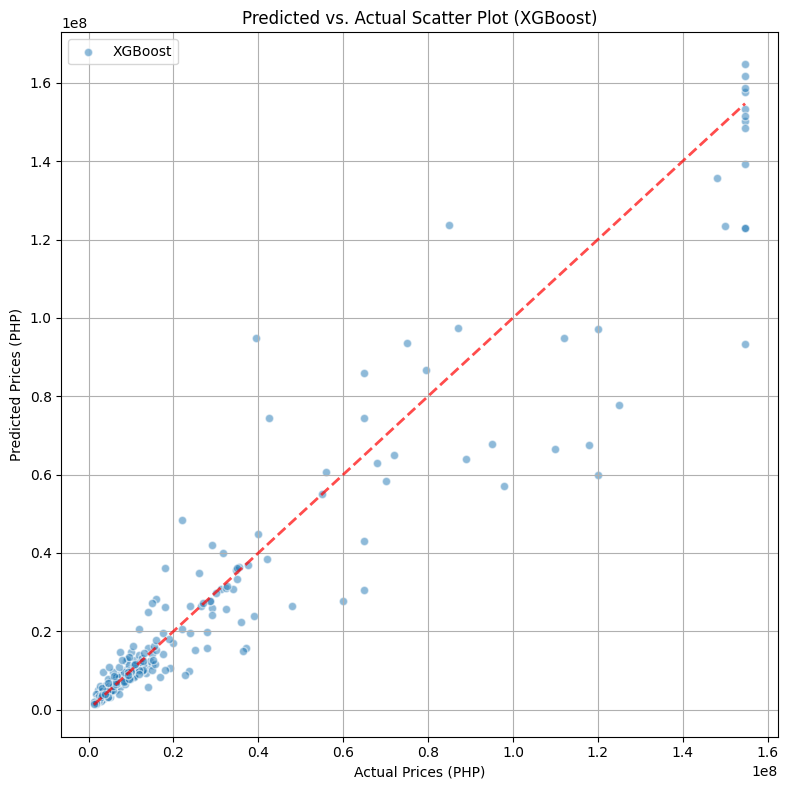

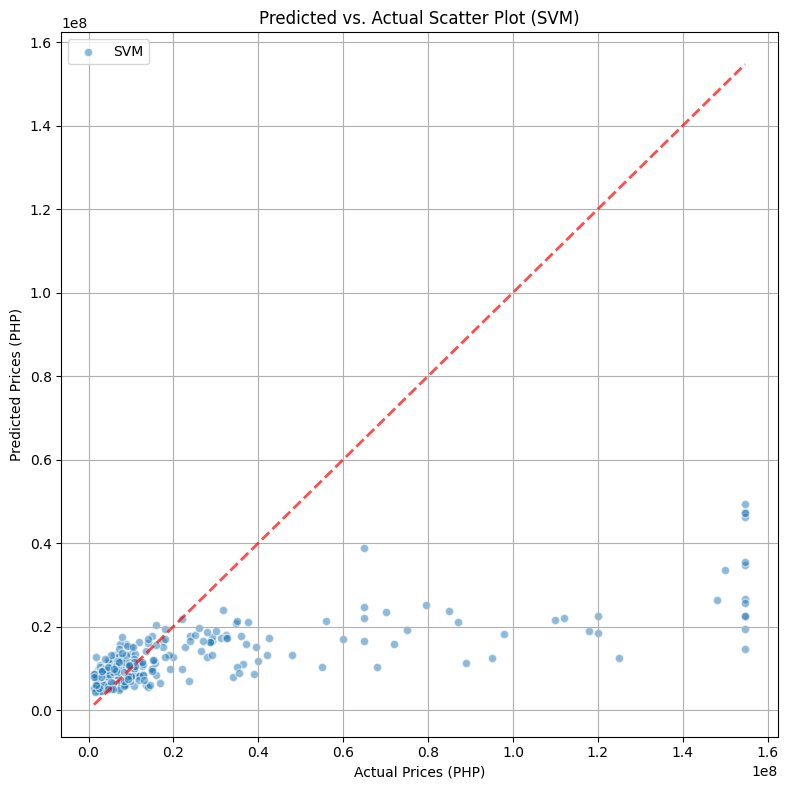

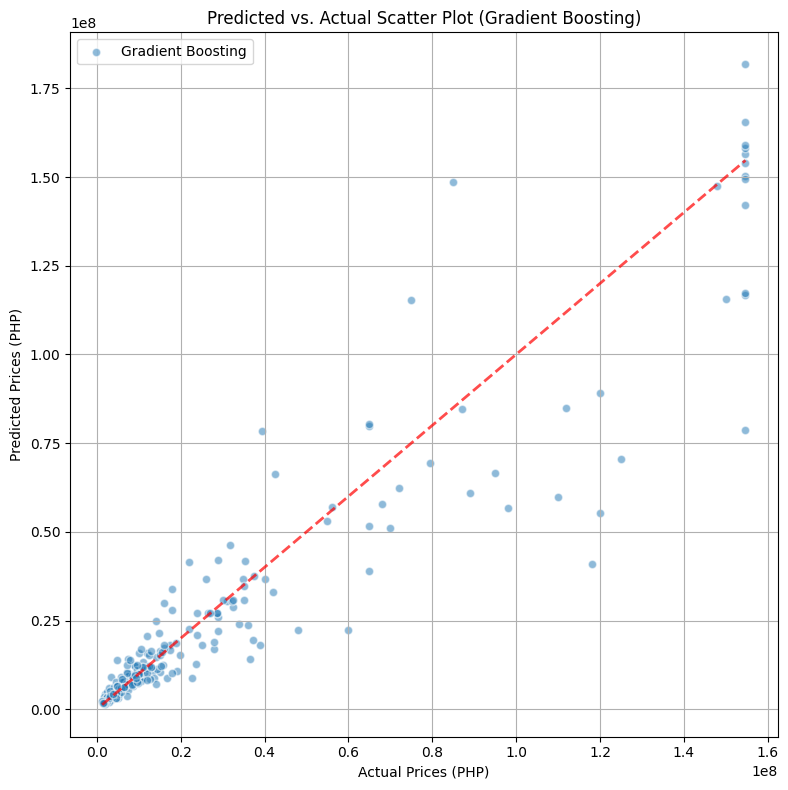

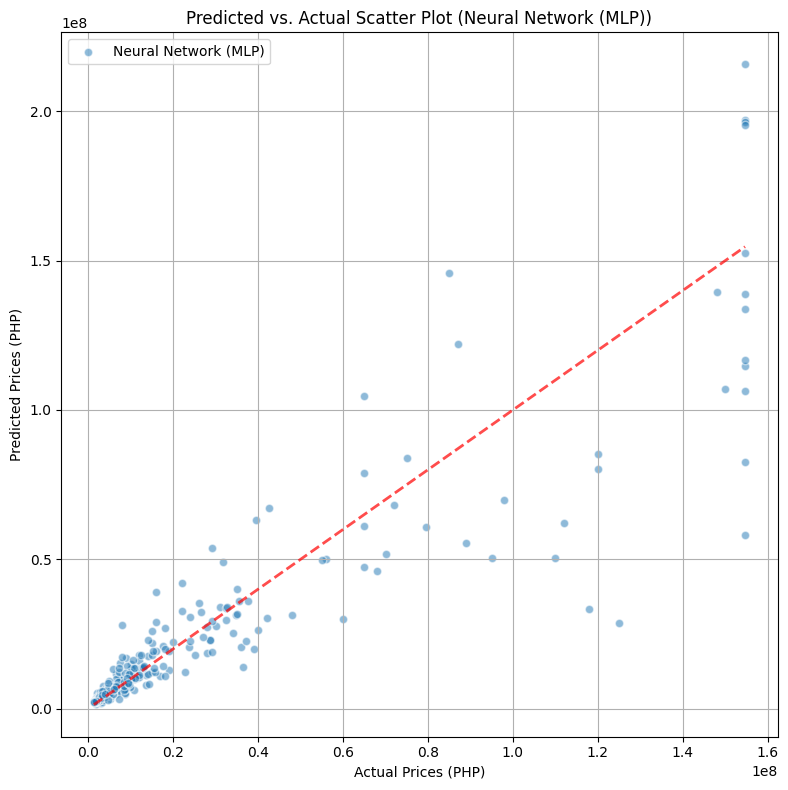

/tmp/ipykernel_568/3824233580.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=fi_df, palette="coolwarm")


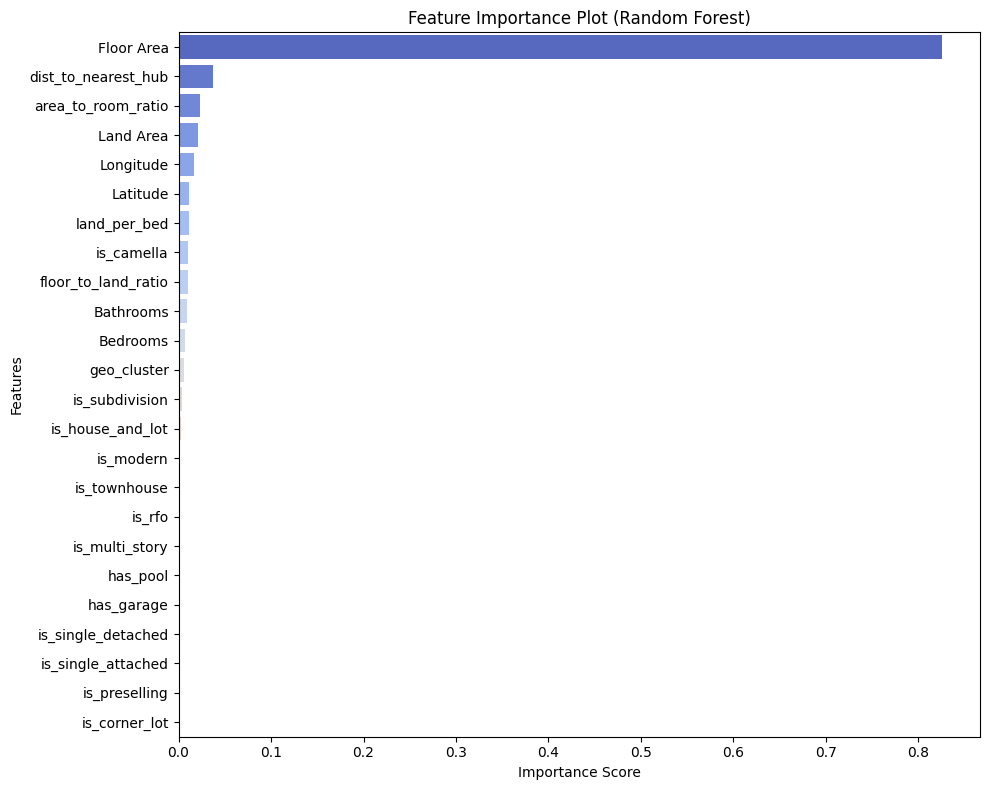

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

# Ensure the directory for saving plots exists
plots_dir = '/content/drive/Shareddrives/shareddrive1/197 final_project/plots/'
os.makedirs(plots_dir, exist_ok=True)

# PLOT 1: Model Performance Comparison (Bar Chart) - MAPE
plt.figure(figsize=(12, 6))
sns.barplot(x=comparison_df["Model"], y=comparison_df["MAPE (%)"], palette="viridis")
plt.ylabel("MAPE (%)")
plt.xlabel("Model")
plt.title("Model Performance Comparison (MAPE)")
plt.ylim(0, comparison_df["MAPE (%)"].max() + 10)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(os.path.join(plots_dir, 'model_performance_comparison.png'), dpi=300)
plt.show()

# PLOT 2: Predicted vs. Actual Scatter Plots (All Models)
for model_name, model in models.items():
    # 1. Predict in Log Space
    y_pred_log = model.predict(X_test)

    # 2. OPTIONAL: Clip log predictions to prevent visual outliers from ruining the plot scale
    # We clip at the max log price found in training + a small buffer
    y_limit = y_train.max() + 0.5
    y_pred_log_clipped = np.clip(y_pred_log, y_train.min(), y_limit)

    # 3. REVERSE TRANSFORM using expm1 (Replaces the price_std math)
    y_test_real = np.expm1(y_test)
    y_pred_real = np.expm1(y_pred_log_clipped)

    plt.figure(figsize=(8, 8))
    plt.scatter(y_test_real, y_pred_real, alpha=0.5, label=f"{model_name}", edgecolors="w")

    # Draw the "Perfect Prediction" Line
    line_range = [y_test_real.min(), y_test_real.max()]
    plt.plot(line_range, line_range, 'r--', lw=2, alpha=0.7)

    plt.xlabel("Actual Prices (PHP)")
    plt.ylabel("Predicted Prices (PHP)")
    plt.title(f"Predicted vs. Actual Scatter Plot ({model_name})")
    plt.grid(True)
    plt.tight_layout()

    # Save the plot
    plt.savefig(os.path.join(plots_dir, f'predicted_vs_actual_scatter_{model_name.replace(" ", "_")}.png'), dpi=300)
    plt.legend()
    plt.show()


In [ ]:
# ==========================================================
# PLOT 3: Feature Importance Plot (XGBoost)
# ==========================================================
best_model_name = "XGBoost" # Changed from Random Forest
best_model = models[best_model_name]
feature_importances = best_model.feature_importances_
feature_names = X.columns

fi_df = pd.DataFrame({"Feature": feature_names, "Importance": feature_importances})
fi_df = fi_df.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 8)) # Increased height for better readability
sns.barplot(x="Importance", y="Feature", data=fi_df, palette="coolwarm")
plt.title("Feature Importance Plot (XGBoost)") # Updated title
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()

# Updated the filename so it doesn't overwrite your old Random Forest plot
plt.savefig(os.path.join(plots_dir, 'feature_importance_plot_xgboost.png'), dpi=300)
plt.show()

NameError: name 'models' is not defined

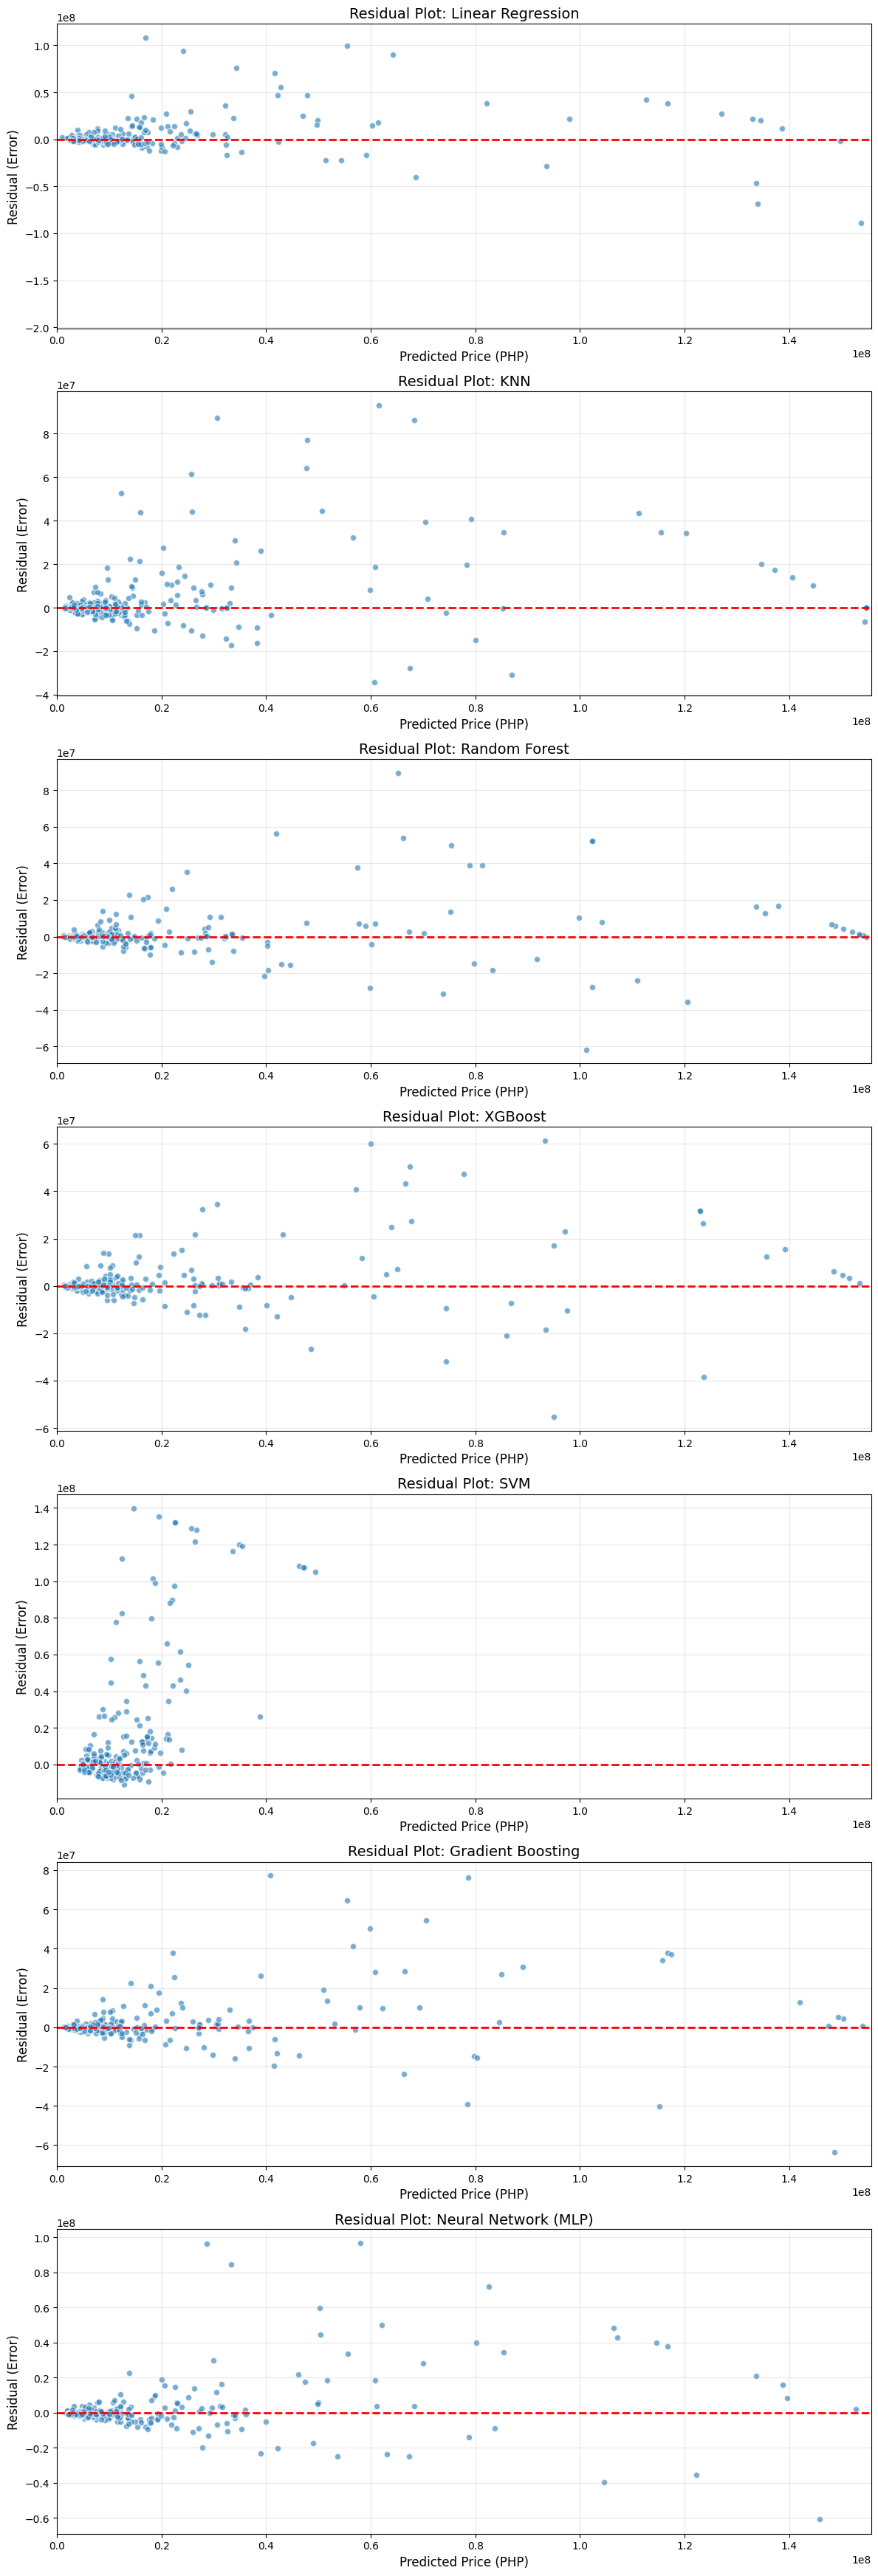

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Residual Plots for all models
num_models = len(models)
num_cols = 1  # one plot per row
num_rows = (num_models // num_cols) + (num_models % num_cols > 0)

plt.figure(figsize=(12, 5 * num_rows))

for idx, (name, model) in enumerate(models.items(), start=1):
    # 1. Generate predictions in log-space
    y_pred_log = model.predict(X_test)

    # 2. Reverse log transform to get back to PHP (Replaces price_std math)
    y_test_real = np.expm1(y_test)
    y_pred_real = np.expm1(y_pred_log)

    # 3. Calculate residuals (Actual - Predicted)
    residuals = y_test_real - y_pred_real

    # Create a subplot
    plt.subplot(num_rows, num_cols, idx)
    plt.scatter(y_pred_real, residuals, alpha=0.6, edgecolors='w')
    plt.axhline(0, color='red', linestyle='--', linewidth=2)

    # 4. CRITICAL: Limit the X-axis to the realistic price range (e.g., 0 to 12M PHP)
    # This prevents outliers from "squishing" your plot
    plt.xlim(0, y_test_real.max() + 1000000)

    plt.title(f"Residual Plot: {name}", fontsize=14)
    plt.xlabel("Predicted Price (PHP)", fontsize=12)
    plt.ylabel("Residual (Error)", fontsize=12)
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/Shareddrives/shareddrive1/197 final_project/plots/residual_plot.png', dpi=300)
plt.show()